In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FILE_PART1 = 'self_play_0-1k.csv'
FILE_PART2 = 'self_play_1-2k.csv'

df1 = pd.read_csv(FILE_PART1)
df2 = pd.read_csv(FILE_PART2)

df1['batch'] = 'Seeds 1–1000'
df2['batch'] = 'Seeds 1001–2000'
df = pd.concat([df1, df2], ignore_index=True)

FOCAL_PROFIT_P_EQ_1_3 = 1/9      # profit per firm at (p,p)=(1/3,1/3)
MONOPOLY_PROFIT_P_EQ_1_2 = 0.125 # profit per firm at (p,p)=(1/2,1/2)

# Remove 'mixed' (empty)
reg_order = ['monopoly_regime', 'focal_equal_price', 'cycling/asymmetric']
colors = {
    'monopoly_regime': '#2ca02c',
    'focal_equal_price': '#6a5acd',
    'cycling/asymmetric': '#ff7f0e'
}

print('Loaded:', len(df1), 'runs (part1),', len(df2), 'runs (part2); total', len(df))

Loaded: 1000 runs (part1), 1000 runs (part2); total 2000


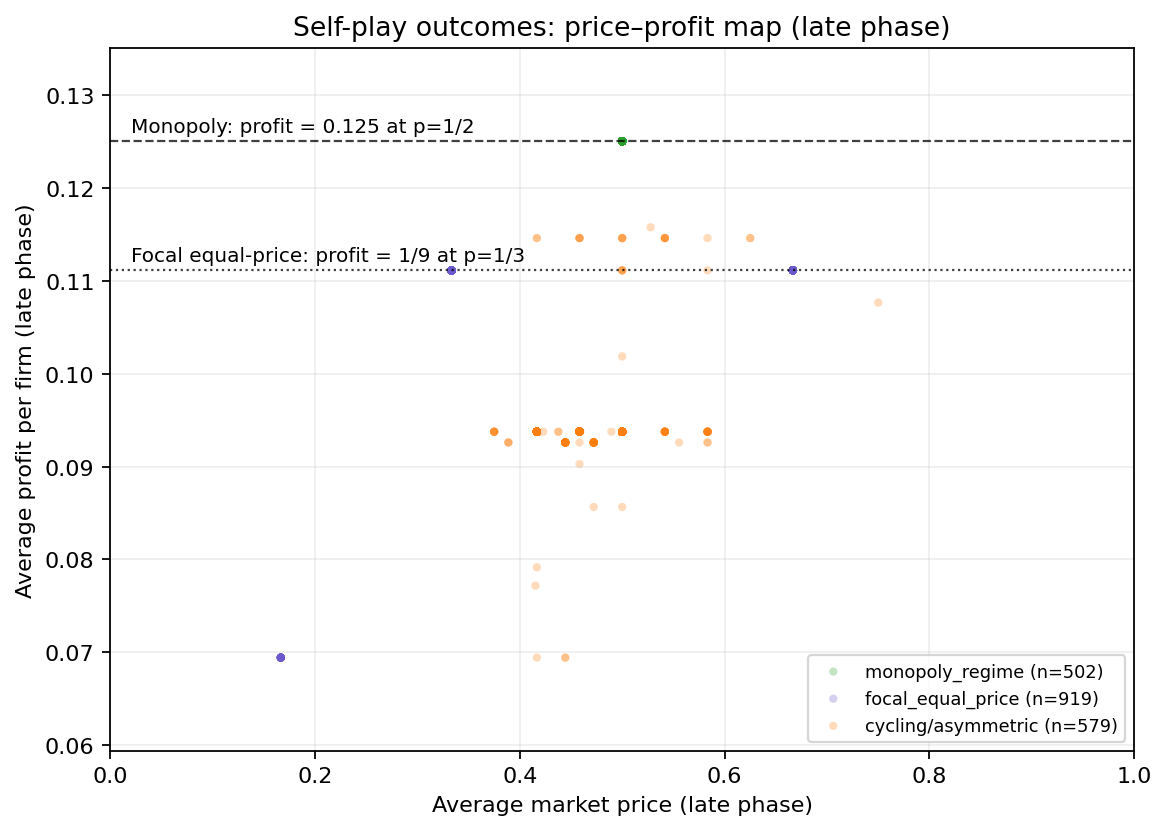

In [13]:
plt.rcParams.update({'figure.dpi': 160})
fig, ax = plt.subplots(figsize=(7.4, 5.3))

for reg in reg_order:
    sub = df[df['regime'] == reg]
    if len(sub) == 0:
        continue
    ax.scatter(
        sub['avg_price'], sub['avg_profit'],
        s=14, alpha=0.28,
        c=colors[reg],
        label=f"{reg} (n={len(sub)})",
        edgecolors='none'
    )

# Reference lines: model-implied focal and monopoly payoffs
ax.axhline(FOCAL_PROFIT_P_EQ_1_3, color='black', linestyle=':', linewidth=1.0, alpha=0.75)
ax.text(0.02, FOCAL_PROFIT_P_EQ_1_3 + 0.001,
        'Focal equal-price: profit = 1/9 at p=1/3', fontsize=9)

ax.axhline(MONOPOLY_PROFIT_P_EQ_1_2, color='black', linestyle='--', linewidth=1.0, alpha=0.75)
ax.text(0.02, MONOPOLY_PROFIT_P_EQ_1_2 + 0.001,
        'Monopoly: profit = 0.125 at p=1/2', fontsize=9)

ax.set_title('Self-play outcomes: price–profit map (late phase)')
ax.set_xlabel('Average market price (late phase)')
ax.set_ylabel('Average profit per firm (late phase)')
ax.set_xlim(0.0, 1.0)
ax.set_ylim(df['avg_profit'].min() - 0.01, df['avg_profit'].max() + 0.01)
ax.grid(True, alpha=0.2)
ax.legend(fontsize=8, frameon=True, loc='lower right')

plt.tight_layout()
plt.show()

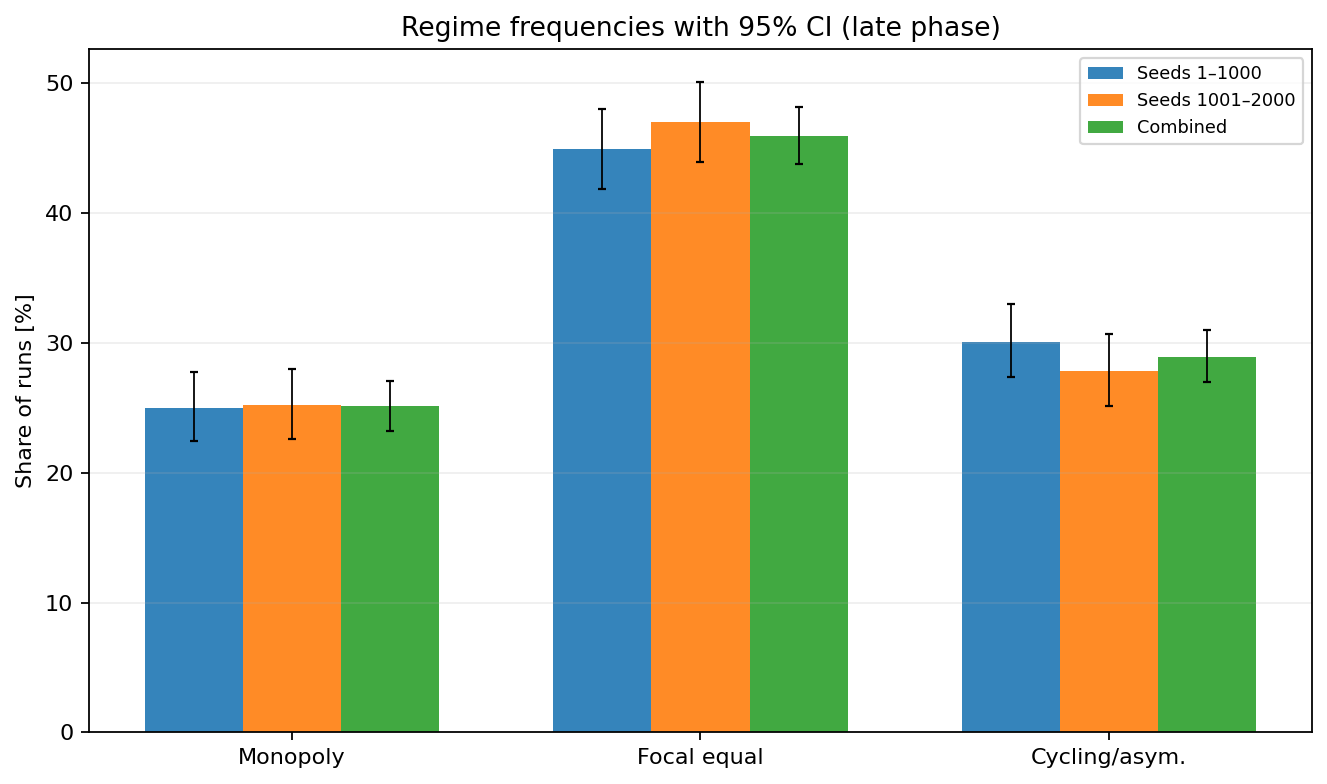

In [14]:
import math

def wilson_ci(k, n, z=1.96):
    p = k / n
    denom = 1 + z*z/n
    center = (p + z*z/(2*n)) / denom
    half = z * math.sqrt(p*(1-p)/n + z*z/(4*n*n)) / denom
    return center - half, center + half

samples = [('Seeds 1–1000', df1), ('Seeds 1001–2000', df2), ('Combined', df)]
rows = []

for label, d in samples:
    n = len(d)
    for reg in reg_order:
        k = int((d['regime'] == reg).sum())
        lo, hi = wilson_ci(k, n)
        rows.append({'sample': label, 'regime': reg, 'share': k/n, 'lo': lo, 'hi': hi})

sd = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8.4, 5.0))
base = np.arange(len(reg_order))
width = 0.24

for i, (label, _) in enumerate(samples):
    sub = sd[sd['sample'] == label].set_index('regime').reindex(reg_order)
    x = base + (i-1)*width
    y = sub['share'].values * 100

    ax.bar(x, y, width, label=label, alpha=0.9)

    yerr_low = (sub['share'] - sub['lo']).values * 100
    yerr_hi  = (sub['hi'] - sub['share']).values * 100
    ax.errorbar(x, y, yerr=[yerr_low, yerr_hi], fmt='none', ecolor='black',
                elinewidth=0.8, capsize=2)

ax.set_xticks(base)
ax.set_xticklabels(['Monopoly', 'Focal equal', 'Cycling/asym.'])
ax.set_ylabel('Share of runs [%]')
ax.set_title('Regime frequencies with 95% CI (late phase)')
ax.grid(axis='y', alpha=0.2)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()